# EDA & Clustering — Dataset 3: Engagement & Activity


## 1. Imports & config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
PALETTE = {0: '#378ADD', 1: '#EF9F27', 2: '#E24B4A'}

In [15]:

# Drop constant column
DROP_COLS = ['total_quizzes_available', 'anonymous_email_hash']
df = pd.read_csv('Dataset_3_Engagement_Activity/dataset3_engagement_activity_scaled_core.csv')
df.drop(columns=DROP_COLS, inplace=True, errors='ignore')

# Encode engagement_profile as binary label
df['engagement_label'] = (df['engagement_profile'] == 'Moderately Engaged').astype(int)
print(f"Shape: {df.shape}")
df.head()

Shape: (626, 20)


,engagement_student_id,quizzes_taken,participation_rate,missing_quiz_rate,avg_normalized_quiz_score,avg_quiz_percent,score_consistency_std_normalized,lowest_normalized_quiz_score,highest_normalized_quiz_score,score_trend_per_quiz,night_activity_ratio,submission_irregularity_hours,active_span_days,performance_score_0_10,consistency_score_0_10,participation_score_0_10,procrastination_score_0_10,engagement_score_0_10,engagement_profile,engagement_label
0,E0001,3,0.1364,0.8636,0.8333,83.33,0.1700,0.6,1.0,-0.0500,0.000000,13.41,14.99,8.33,8.30,1.36,2.83,4.49,Disengaged,0
1,E0002,11,0.5000,0.5000,0.7182,71.82,0.1336,0.5,1.0,0.0011,0.181818,2824.05,547.06,7.18,8.66,5.00,5.23,6.28,Moderately Engaged,1
2,E0003,6,0.2727,0.7273,0.8833,88.33,0.0687,0.8,1.0,-0.0314,0.000000,246.74,85.14,8.83,9.31,2.73,5.18,5.57,Disengaged,0
3,E0004,12,0.5455,0.4545,0.8917,89.17,0.0862,0.7,1.0,-0.0019,0.083333,2730.32,532.95,8.92,9.14,5.45,4.70,7.06,Moderately Engaged,1
4,E0005,14,0.6364,0.3636,0.7286,72.86,0.1532,0.5,1.0,-0.0015,0.000000,2542.04,532.95,7.29,8.47,6.36,4.09,7.02,Moderately Engaged,1


In [16]:
miss = df.isnull().sum()
print(miss[miss > 0].to_string() if miss.any() else '  No missing values ✓')


  No missing values ✓


##  Engagement profile breakdown

The dataset comes with a pre-assigned `engagement_profile` label:  
**Disengaged** (357 students) and **Moderately Engaged** (269 students).  
There is no 'Highly Engaged' group — the platform data reflects a population  
where full participation (all 22 quizzes) is rare.


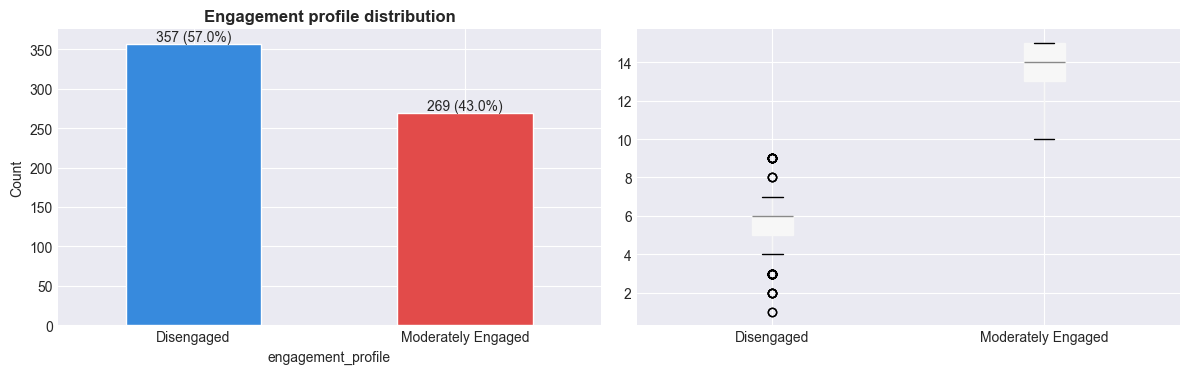


=== Profile means — key features ===
                    performance_score_0_10  consistency_score_0_10  participation_score_0_10  procrastination_score_0_10  engagement_score_0_10  participation_rate  missing_quiz_rate  night_activity_ratio  avg_quiz_percent  active_span_days
engagement_profile                                                                                                                                                                                                                              
Disengaged                           8.079                   8.692                     2.475                       5.302                  5.119               0.247              0.753                 0.041            80.795            91.103
Moderately Engaged                   8.535                   8.732                     6.230                       4.656                  7.307               0.623              0.377                 0.133            85.348           526.44

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
CLUSTER_COLS = [
    'performance_score_0_10', 'consistency_score_0_10',
    'participation_score_0_10', 'procrastination_score_0_10',
    'engagement_score_0_10'
]
# Profile counts
prof = df['engagement_profile'].value_counts()
prof.plot.bar(ax=axes[0], color=['#378ADD','#E24B4A'], edgecolor='white', rot=0)
axes[0].set_title('Engagement profile distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Quizzes taken by profile
df.boxplot(column='quizzes_taken', by='engagement_profile', ax=axes[1], patch_artist=True)
axes[1].set_title('Quizzes taken by profile', fontweight='bold')
axes[1].set_xlabel('')
plt.sca(axes[1]); plt.title('')
fig.suptitle('')
plt.tight_layout()
plt.show()

print('\n=== Profile means — key features ===')
key_cols = CLUSTER_COLS + ['participation_rate', 'missing_quiz_rate',
                            'night_activity_ratio', 'avg_quiz_percent', 'active_span_days']
print(df.groupby('engagement_profile')[key_cols].mean().round(3).to_string())


##  Descriptive statistics

In [18]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
stats = df[num_cols].describe().T
stats['skewness'] = df[num_cols].skew().round(3)
stats['kurtosis'] = df[num_cols].kurt().round(3)
stats.round(3)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
quizzes_taken,626.0,8.994,4.319,1.000,6.000,6.000,14.000,15.000,0.280,-1.582
participation_rate,626.0,0.409,0.196,0.046,0.273,0.273,0.636,0.682,0.280,-1.582
missing_quiz_rate,626.0,0.591,0.196,0.318,0.364,0.727,0.727,0.954,-0.280,-1.582
avg_normalized_quiz_score,626.0,0.828,0.093,0.133,0.775,0.839,0.900,1.000,-1.490,6.272
avg_quiz_percent,626.0,82.752,9.323,13.330,77.500,83.925,90.000,100.000,-1.490,6.272
score_consistency_std_normalized,626.0,0.129,0.049,0.000,0.094,0.126,0.160,0.356,0.478,0.796
lowest_normalized_quiz_score,626.0,0.600,0.157,0.000,0.500,0.600,0.700,1.000,-0.598,0.693
highest_normalized_quiz_score,626.0,0.977,0.067,0.300,1.000,1.000,1.000,1.000,-4.877,36.339
score_trend_per_quiz,626.0,-0.008,0.035,-0.400,-0.017,-0.006,0.000,0.150,-2.152,27.858
night_activity_ratio,626.0,0.081,0.103,0.000,0.000,0.000,0.143,0.667,1.435,2.673


## Distributions — activity & score features

### Raw activity features
`participation_rate` and `missing_quiz_rate` are mirror images of each other
(they sum to 1.0), confirming perfect inverse correlation. Both show a bimodal
distribution — students cluster into two groups: those who attempt most quizzes
and those who skip most of them. `quizzes_taken` reflects this directly, with
spikes at 6 (27.3% participation) and 15 (68% participation).
`night_activity_ratio` is extremely right-skewed (median = 0) — most students
submit during the day; night submissions are a minority signal but meaningful
for procrastination detection. `active_span_days` is strongly bimodal: one group
active for ~85 days (a single semester window) and another for ~547 days
(multi-semester engagement).

### Composite scores (0–10 scale)
`performance_score_0_10` and `consistency_score_0_10` are left-skewed and
tightly clustered near 8–9 — most students who participate perform well and
consistently. `participation_score_0_10` is bimodal, directly mirroring the
two participation groups. `procrastination_score_0_10` is approximately normal
(mean 5.0), well-distributed across the population. `engagement_score_0_10`
is the most normally distributed composite — confirming it is well-calibrated
as the primary clustering and target feature.


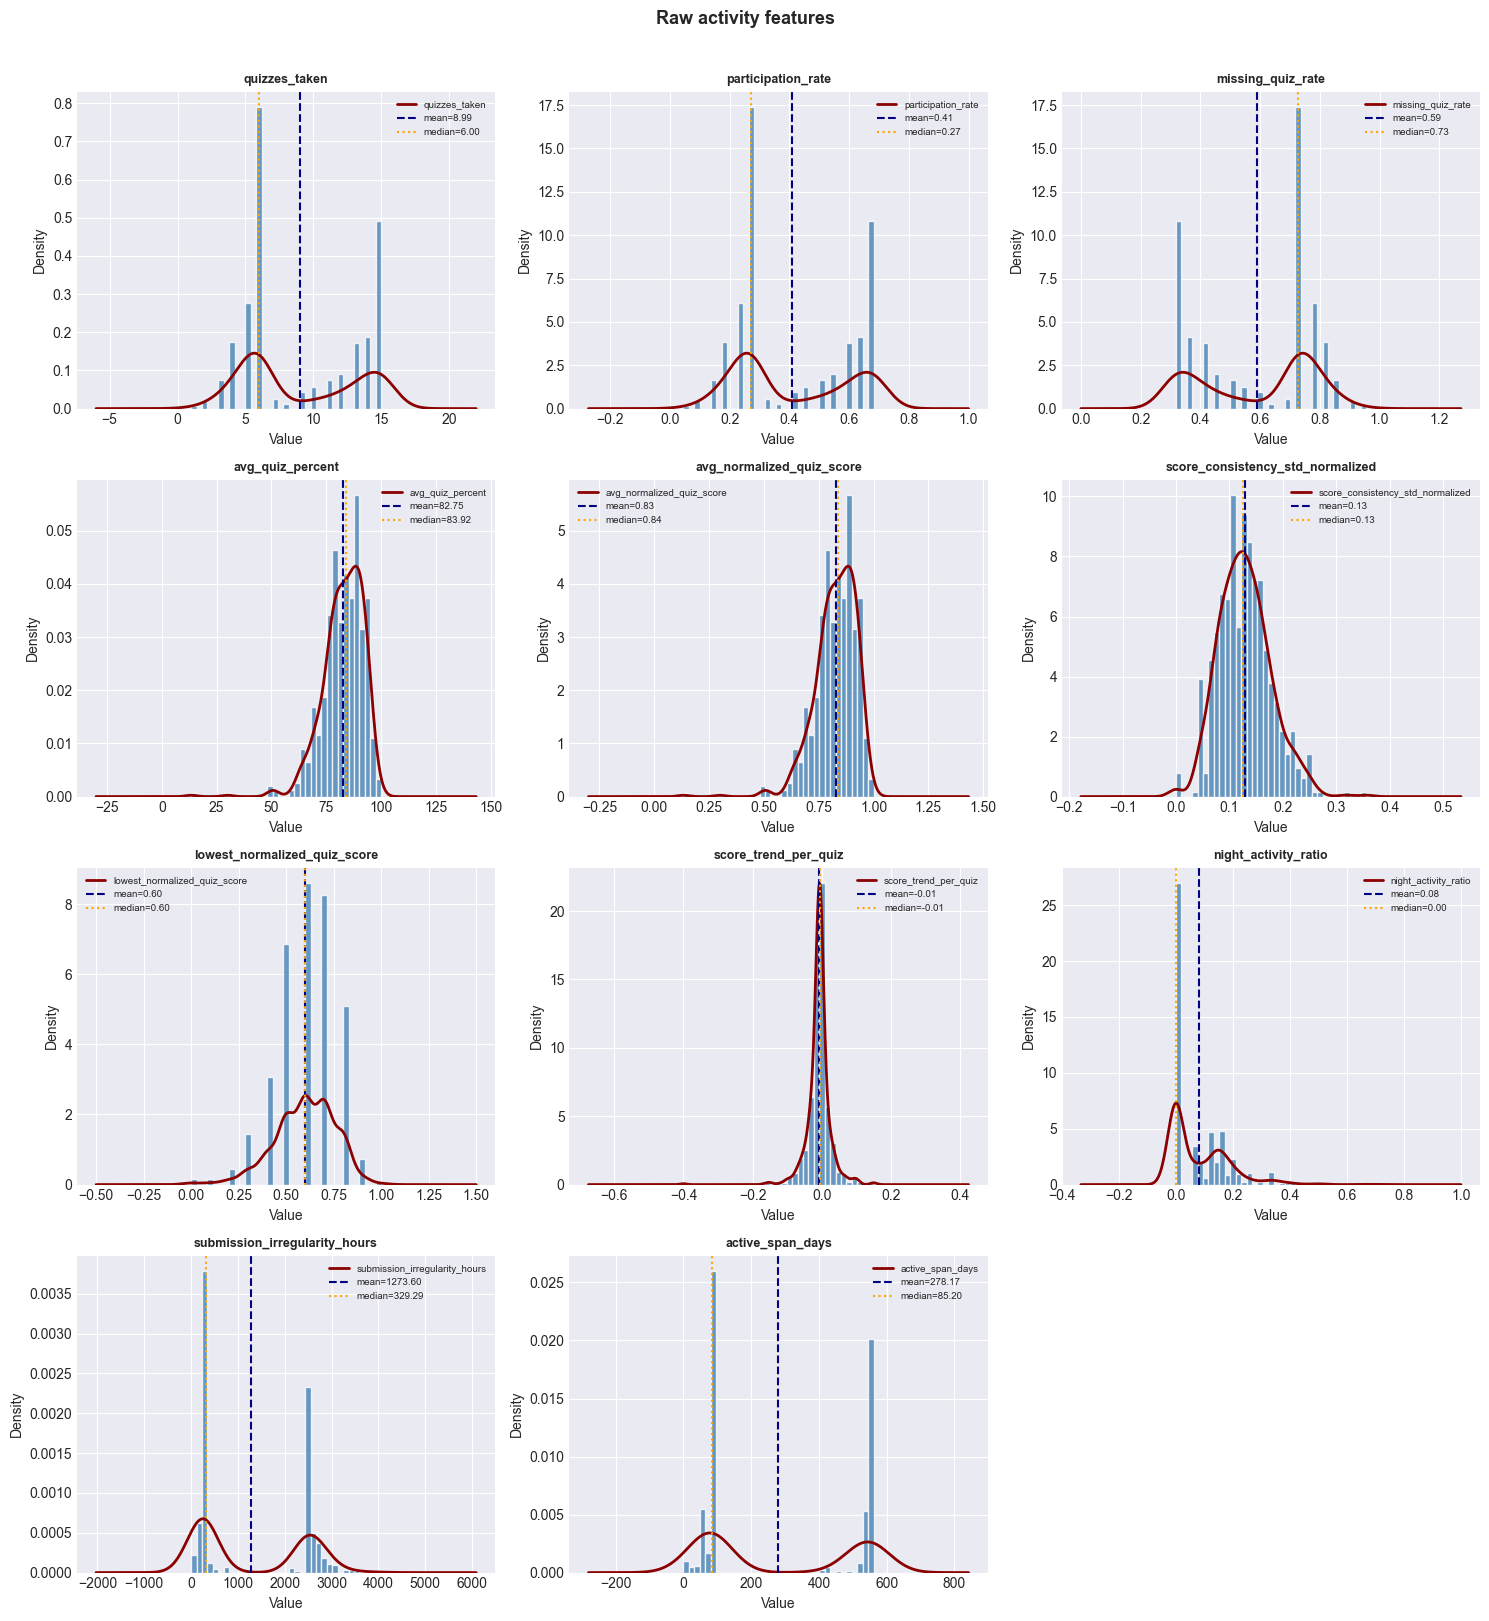

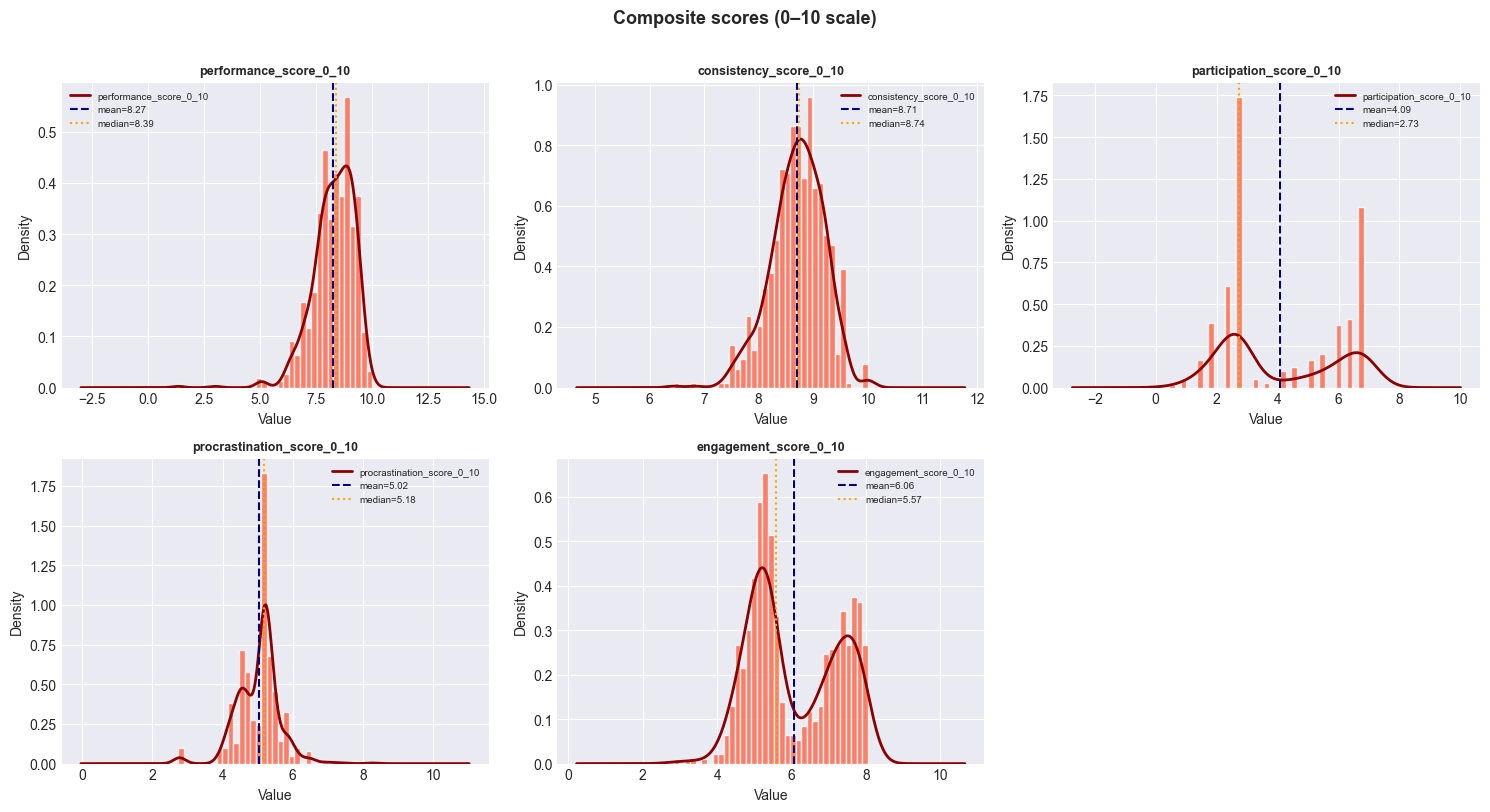

In [19]:
def dist_grid(df, cols, title, color='steelblue', ncols=3):
    cols = [c for c in cols if c in df.columns]
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cols):
        data = df[col].dropna()
        axes[i].hist(data, bins=35, color=color, edgecolor='white', alpha=0.8, density=True)
        try:
            data.plot.kde(ax=axes[i], color='darkred', linewidth=2)
        except Exception:
            pass
        axes[i].axvline(data.mean(),   color='navy',   ls='--', lw=1.5, label=f'mean={data.mean():.2f}')
        axes[i].axvline(data.median(), color='orange', ls=':',  lw=1.5, label=f'median={data.median():.2f}')
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].legend(fontsize=7)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

raw_cols = ['quizzes_taken', 'participation_rate', 'missing_quiz_rate',
            'avg_quiz_percent', 'avg_normalized_quiz_score',
            'score_consistency_std_normalized', 'lowest_normalized_quiz_score',
            'score_trend_per_quiz', 'night_activity_ratio',
            'submission_irregularity_hours', 'active_span_days']
dist_grid(df, raw_cols, 'Raw activity features', color='steelblue')

dist_grid(df, CLUSTER_COLS, 'Composite scores (0–10 scale)', color='tomato')


### Distributions
- `participation_rate` and `missing_quiz_rate` are exact mirror images (r = −1.0) — only one should be used in modelling.
- `quizzes_taken` is bimodal with spikes at 6 and 15 — students either attempt most quizzes or very few, with little in between.
- `night_activity_ratio` is extremely right-skewed (median = 0) — night submission is rare but a meaningful procrastination signal.
- `active_span_days` is strongly bimodal: ~85 days (single semester) vs ~547 days (multi-semester) — likely reflecting two different cohorts or enrolment periods.
- Composite scores (`performance_score_0_10`, `consistency_score_0_10`) are left-skewed — students who participate tend to perform well.


##  Outlier analysis (IQR method)

=== Outlier summary ===
                                    Q1        Q3       IQR  mild_outliers  mild_pct  extreme_outliers  extreme_pct
feature                                                                                                           
procrastination_score_0_10       4.645     5.320     0.675             23      3.67                 2         0.32
night_activity_ratio             0.000     0.143     0.143             13      2.08                 1         0.16
performance_score_0_10           7.750     9.000     1.250              7      1.12                 2         0.32
consistency_score_0_10           8.402     9.060     0.658              4      0.64                 0         0.00
participation_score_0_10         2.730     6.360     3.630              0      0.00                 0         0.00
engagement_score_0_10            5.110     7.250     2.140              0      0.00                 0         0.00
participation_rate               0.273     0.636     0.3

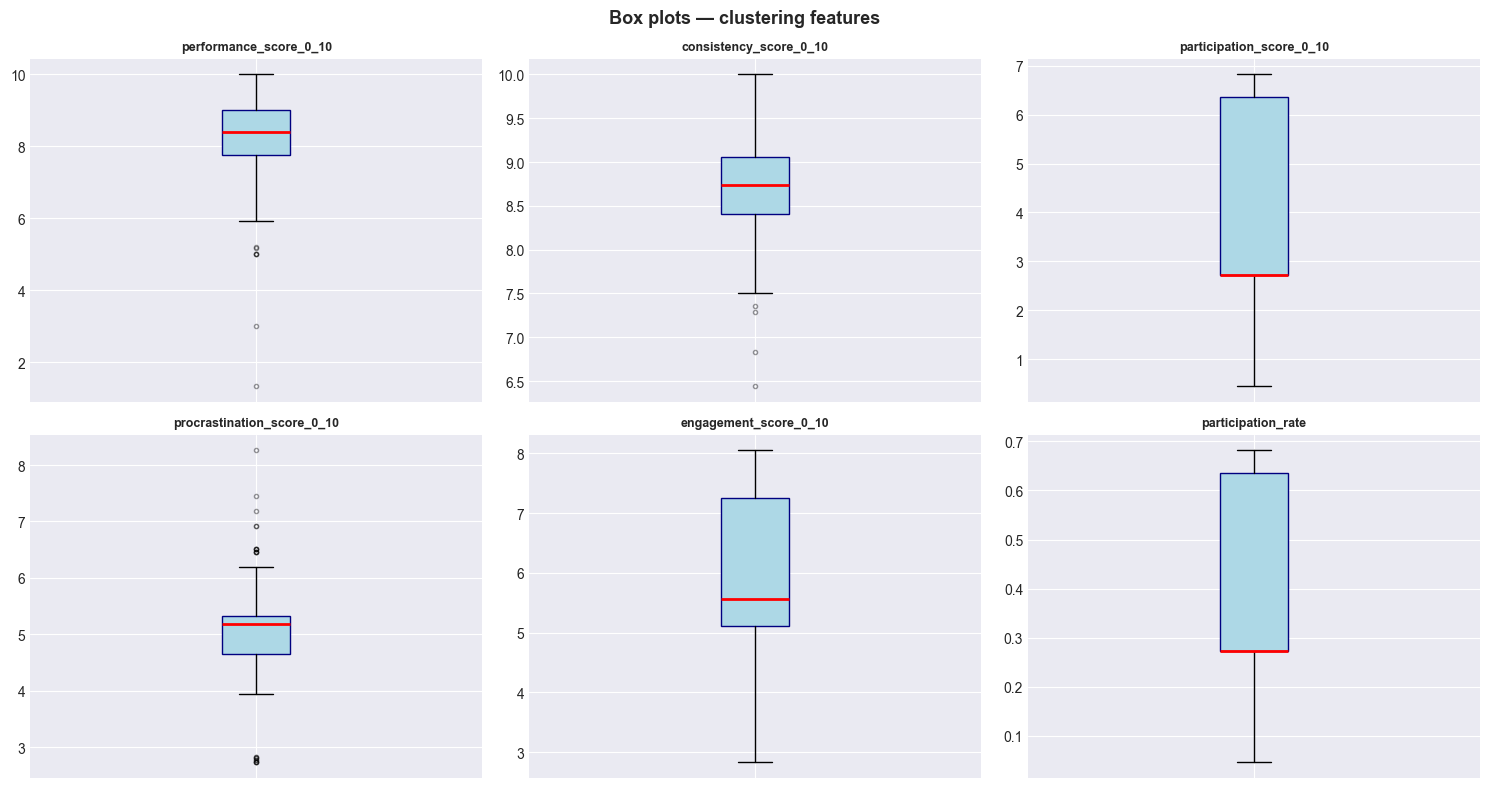

In [20]:
def iqr_outliers(df, cols):
    rows = []
    for c in [x for x in cols if x in df.columns]:
        s = df[c].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        mild  = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
        ext   = ((s < q1 - 3.0*iqr) | (s > q3 + 3.0*iqr)).sum()
        rows.append({
            'feature': c, 'Q1': round(q1,3), 'Q3': round(q3,3), 'IQR': round(iqr,3),
            'mild_outliers': mild, 'mild_pct': round(mild/len(s)*100,2),
            'extreme_outliers': ext, 'extreme_pct': round(ext/len(s)*100,2)
        })
    return pd.DataFrame(rows).set_index('feature')

check_cols = CLUSTER_COLS + ['participation_rate', 'missing_quiz_rate',
                              'night_activity_ratio', 'submission_irregularity_hours',
                              'active_span_days']
outlier_report = iqr_outliers(df, check_cols)
print('=== Outlier summary ===')
print(outlier_report.sort_values('mild_pct', ascending=False).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
plot_cols = CLUSTER_COLS + ['participation_rate']
for i, col in enumerate(plot_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xticklabels([])
fig.suptitle('Box plots — clustering features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##  Engagement score deep-dive

`engagement_score_0_10` is the primary composite signal.  
It is examined by engagement profile and by quiz participation group.


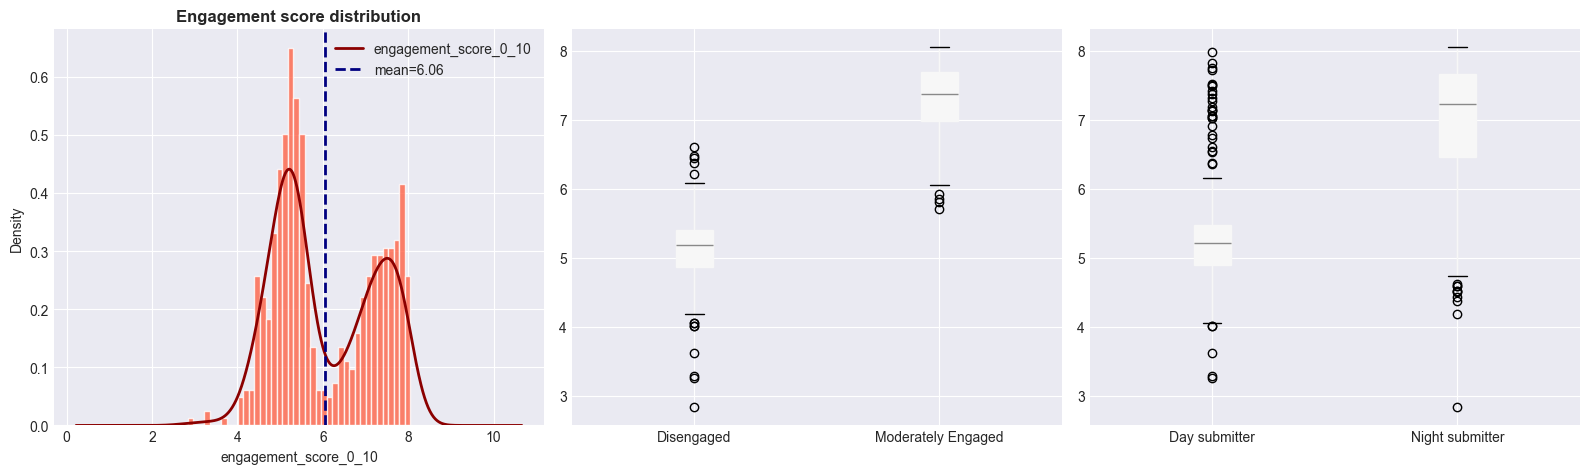


=== Engagement score stats by profile ===
                    count   mean    std   min   25%   50%  75%   max
engagement_profile                                                  
Disengaged          357.0  5.119  0.465  2.83  4.87  5.19  5.4  6.61
Moderately Engaged  269.0  7.307  0.504  5.71  6.99  7.38  7.7  8.05


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution
eng = df['engagement_score_0_10']
axes[0].hist(eng, bins=40, color='tomato', edgecolor='white', alpha=0.8, density=True)
eng.plot.kde(ax=axes[0], color='darkred', linewidth=2)
axes[0].axvline(eng.mean(), color='navy', ls='--', lw=2, label=f'mean={eng.mean():.2f}')
axes[0].set_title('Engagement score distribution', fontweight='bold')
axes[0].set_xlabel('engagement_score_0_10')
axes[0].legend()

# By profile
df.boxplot(column='engagement_score_0_10', by='engagement_profile', ax=axes[1], patch_artist=True)
axes[1].set_title('Engagement score by profile', fontweight='bold')
axes[1].set_xlabel('')
plt.sca(axes[1]); plt.title('')

# By night activity (binary: day vs night submitter)
df['night_submitter'] = (df['night_activity_ratio'] > 0).map({True: 'Night submitter', False: 'Day submitter'})
df.boxplot(column='engagement_score_0_10', by='night_submitter', ax=axes[2], patch_artist=True)
axes[2].set_title('Engagement score: day vs night submitters', fontweight='bold')
axes[2].set_xlabel('')
plt.sca(axes[2]); plt.title('')

fig.suptitle('')
plt.tight_layout()
plt.show()

print('\n=== Engagement score stats by profile ===')
print(df.groupby('engagement_profile')['engagement_score_0_10']
        .describe().round(3).to_string())


##  Correlation analysis

=== Top 12 strongest correlations ===
                       feature_1                feature_2      r
                   quizzes_taken       participation_rate  1.000
                   quizzes_taken        missing_quiz_rate -1.000
                   quizzes_taken participation_score_0_10  1.000
              participation_rate        missing_quiz_rate -1.000
              participation_rate participation_score_0_10  1.000
               missing_quiz_rate participation_score_0_10 -1.000
       avg_normalized_quiz_score         avg_quiz_percent  1.000
       avg_normalized_quiz_score   performance_score_0_10  1.000
                avg_quiz_percent   performance_score_0_10  1.000
score_consistency_std_normalized   consistency_score_0_10 -1.000
   submission_irregularity_hours         active_span_days  0.983
                   quizzes_taken    engagement_score_0_10  0.970


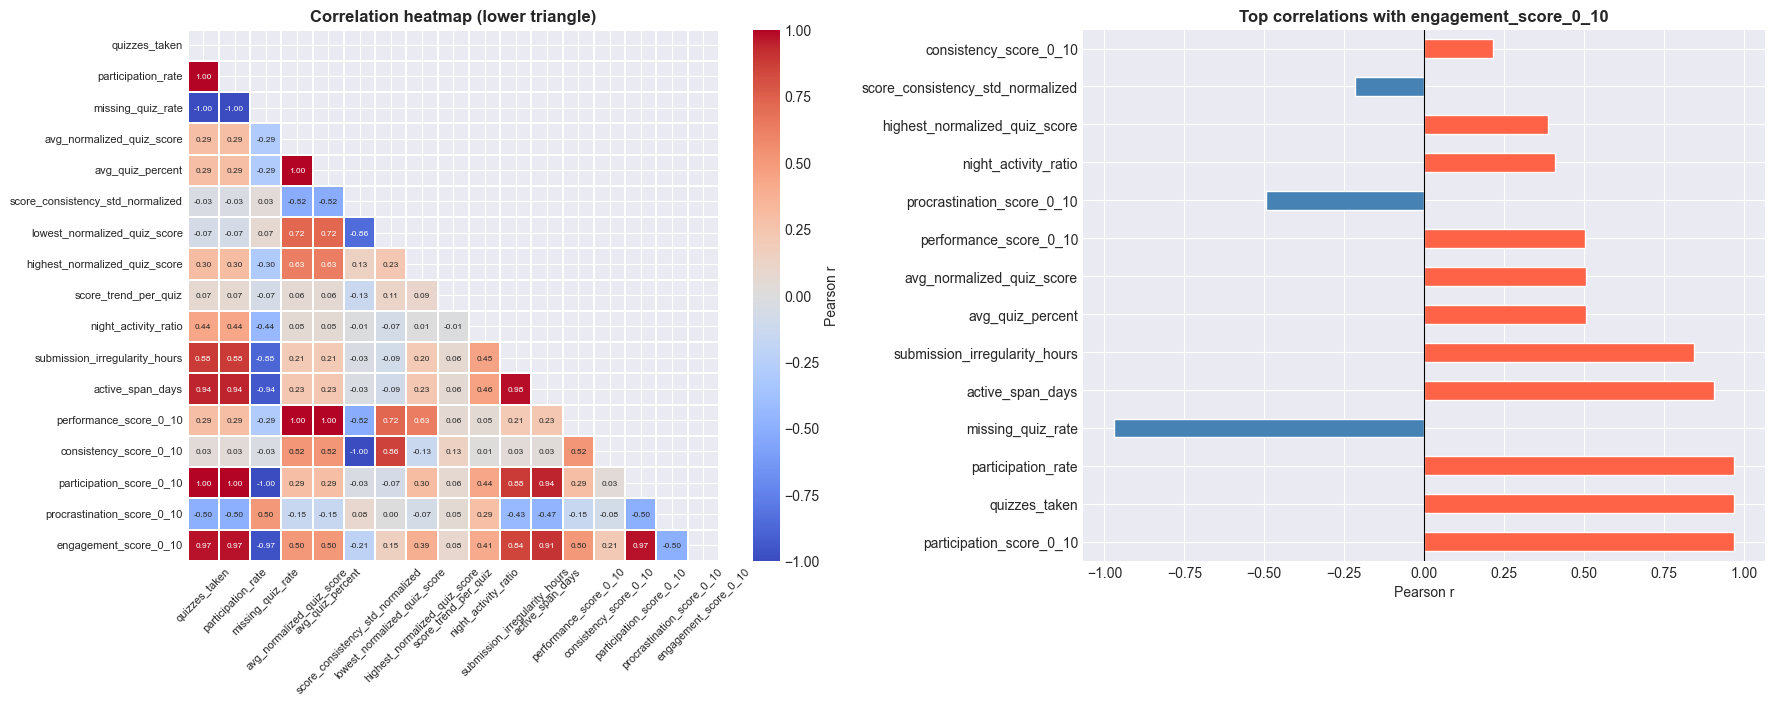

In [22]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'engagement_label']
corr = df[num_cols].corr()

pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        pairs.append({'feature_1': corr.columns[i], 'feature_2': corr.columns[j],
                      'r': round(corr.iloc[i,j], 3)})
top_pairs = (pd.DataFrame(pairs)
               .assign(abs_r=lambda d: d['r'].abs())
               .nlargest(12, 'abs_r')[['feature_1','feature_2','r']])
print('=== Top 12 strongest correlations ===')
print(top_pairs.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], linewidths=0.3,
            annot_kws={'size': 6}, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Correlation heatmap (lower triangle)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

eng_corr = corr['engagement_score_0_10'].drop('engagement_score_0_10').sort_values(key=abs, ascending=False).head(14)
colors = ['tomato' if v > 0 else 'steelblue' for v in eng_corr]
eng_corr.plot.barh(ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson r')
axes[1].set_title('Top correlations with engagement_score_0_10', fontweight='bold')

plt.tight_layout()
plt.show()


### Correlations
- `participation_score_0_10`, `quizzes_taken`, and `participation_rate` all correlate at r = 0.97 with `engagement_score_0_10` — participation is by far the dominant driver of engagement.
- `active_span_days` (r = 0.906) and `submission_irregularity_hours` (r = 0.845) are the next strongest signals.
- `procrastination_score_0_10` (r = −0.496) is a meaningful negative predictor — more procrastination, lower engagement.

##  Pairplot — separability check

Coloured by `engagement_profile`.  
Dataset 3 has the cleanest cluster separation of all three datasets,  
driven primarily by `participation_score_0_10` and `engagement_score_0_10`.


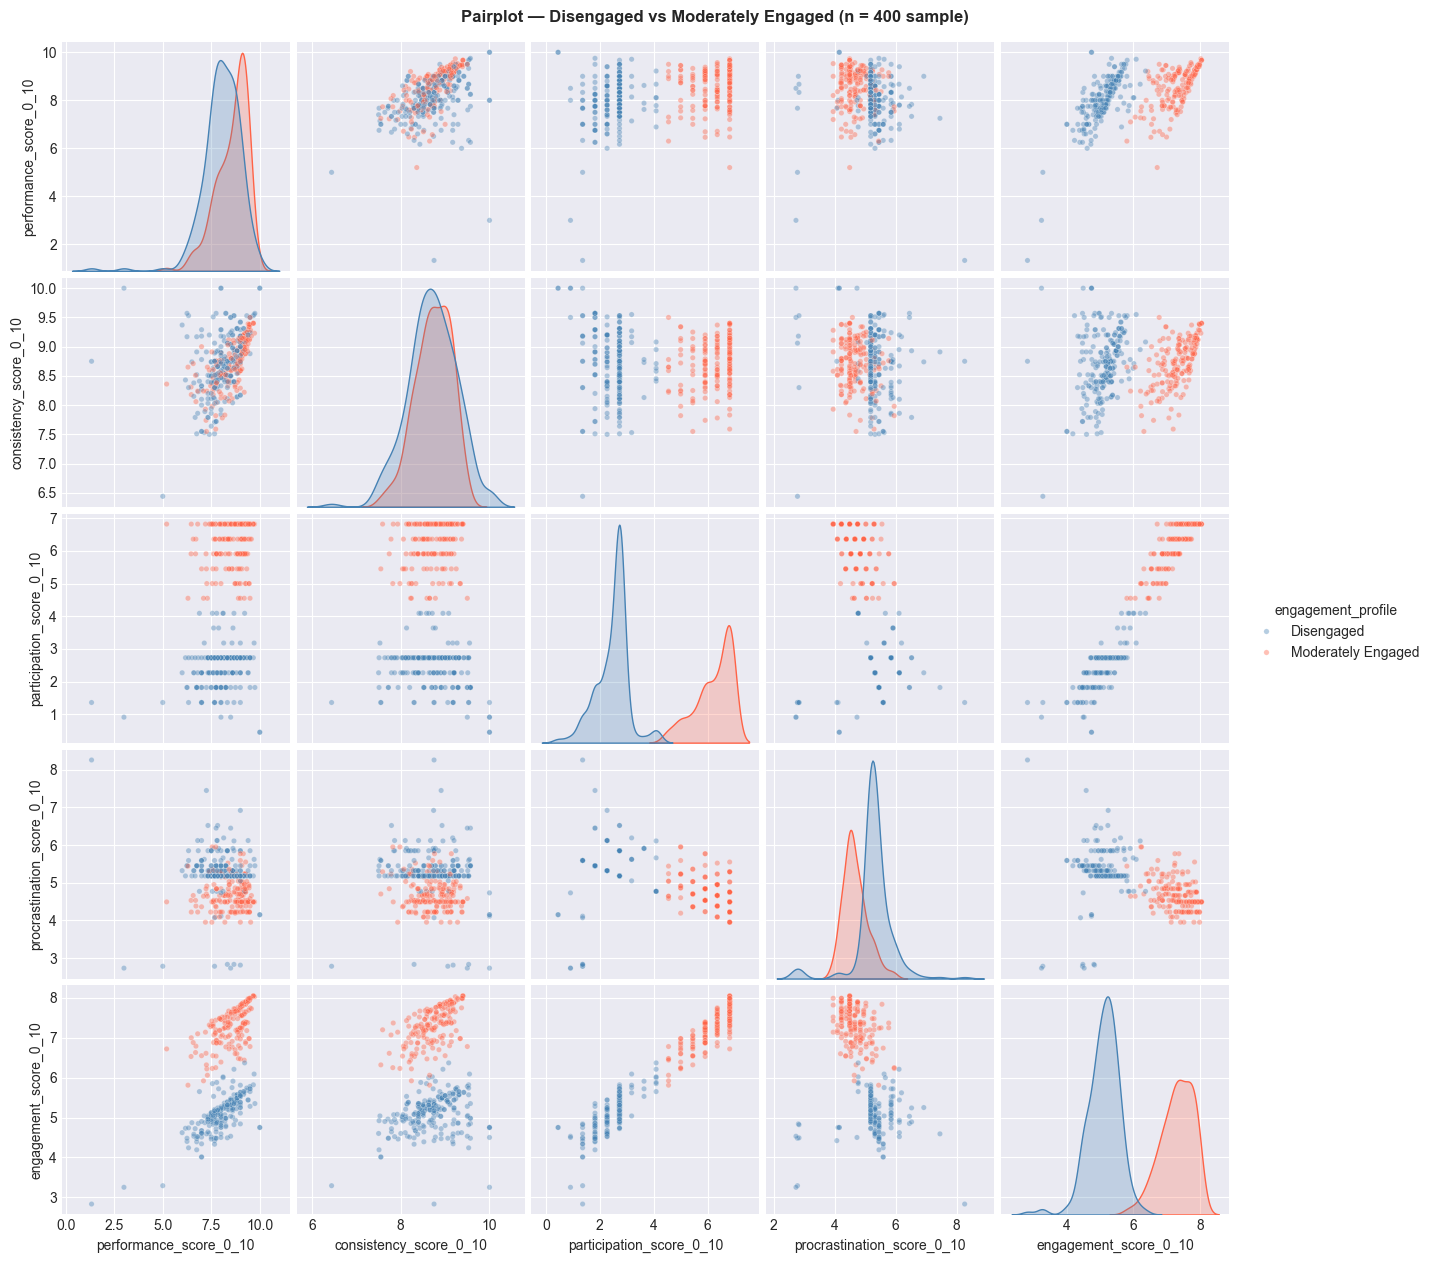

In [23]:
sample = (df[CLUSTER_COLS + ['engagement_profile']].dropna()
            .sample(min(400, len(df)), random_state=42))

pp = sns.pairplot(sample, vars=CLUSTER_COLS, hue='engagement_profile',
                  palette={'Disengaged': 'steelblue', 'Moderately Engaged': 'tomato'},
                  plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
pp.fig.suptitle('Pairplot — Disengaged vs Moderately Engaged (n = 400 sample)',
                y=1.01, fontsize=12, fontweight='bold')
plt.show()


## Class imbalance (engagement profile)

=== Engagement label distribution ===
                        count   pct
engagement_label                   
Disengaged (0)            357  57.0
Moderately Engaged (1)    269  43.0

Imbalance ratio: 1.33:1
✓  Mild imbalance — class_weight="balanced" is sufficient


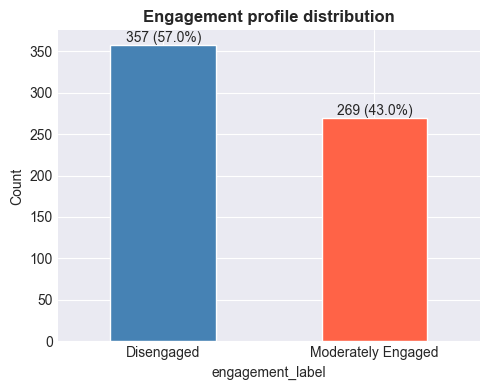

In [24]:
label_counts = df['engagement_label'].value_counts()
label_pct    = df['engagement_label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': label_counts, 'pct': label_pct.round(1)})
summary.index = summary.index.map({0: 'Disengaged (0)', 1: 'Moderately Engaged (1)'})
print('=== Engagement label distribution ===')
print(summary.to_string())

ratio = label_counts.max() / label_counts.min()
print(f'\nImbalance ratio: {ratio:.2f}:1')
if ratio > 3:
    print('⚠  Significant imbalance — consider SMOTE or class_weight="balanced"')
else:
    print('✓  Mild imbalance — class_weight="balanced" is sufficient')

fig, ax = plt.subplots(figsize=(5, 4))
label_counts.rename({0: 'Disengaged', 1: 'Moderately Engaged'}).plot.bar(
    ax=ax, color=['steelblue', 'tomato'], edgecolor='white', rot=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.set_title('Engagement profile distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### Class imbalance
- Disengaged: 357 (57%) vs Moderately Engaged: 269 (43%) — mild imbalance.
- `class_weight='balanced'` is sufficient; SMOTE not required.

##  K-Means clustering — k selection